<a href="https://colab.research.google.com/github/Darsini004/ML-tasks/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [25]:
data = pd.read_csv("Throttling.csv")

print(data.head())

             Timestamp  CPU_Usage_Percent  RAM_Usage_Percent  \
0  2026-01-31 11:20:00              67.36              39.28   
1  2026-01-08 15:15:00              38.73              30.87   
2  2026-02-03 07:40:00              86.89              26.21   
3  2026-01-30 11:30:00              60.52              47.10   
4  2026-01-12 12:10:00              76.75              61.17   

   GPU_Usage_Percent  Ambient_Temperature_C  CPU_Temperature_C  \
0              55.58                  31.06              75.28   
1              51.24                  33.79              67.94   
2              61.50                  13.80              74.72   
3              70.38                  28.82              72.84   
4             100.00                  23.38              83.14   

   GPU_Temperature_C  Fan_Speed_RPM  CPU_Frequency_MHz  Battery_Temperature_C  \
0              63.88         3822.0             3010.0                  32.76   
1              61.45         2705.0             3511.0  

In [26]:
before = len(data)

data = data.drop_duplicates()

after = len(data)

print("Duplicates Removed:", before - after)

Duplicates Removed: 50


In [27]:
print("Shape:", data.shape)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Shape: (10000, 14)

Data Types:
Timestamp                 object
CPU_Usage_Percent        float64
RAM_Usage_Percent        float64
GPU_Usage_Percent        float64
Ambient_Temperature_C    float64
CPU_Temperature_C        float64
GPU_Temperature_C        float64
Fan_Speed_RPM            float64
CPU_Frequency_MHz        float64
Battery_Temperature_C    float64
Battery_Level_Percent    float64
Power_Consumption_W      float64
Process_Count            float64
Thermal_Throttling        object
dtype: object

Missing Values:
Timestamp                 0
CPU_Usage_Percent         0
RAM_Usage_Percent        35
GPU_Usage_Percent         0
Ambient_Temperature_C     0
CPU_Temperature_C         0
GPU_Temperature_C        35
Fan_Speed_RPM             0
CPU_Frequency_MHz        35
Battery_Temperature_C    35
Battery_Level_Percent     0
Power_Consumption_W      35
Process_Count             0
Thermal_Throttling        0
dtype: int64


In [28]:
data.columns = (
    data.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("\nCleaned Columns:")
print(data.columns)


Cleaned Columns:
Index(['Timestamp', 'CPU_Usage_Percent', 'RAM_Usage_Percent',
       'GPU_Usage_Percent', 'Ambient_Temperature_C', 'CPU_Temperature_C',
       'GPU_Temperature_C', 'Fan_Speed_RPM', 'CPU_Frequency_MHz',
       'Battery_Temperature_C', 'Battery_Level_Percent', 'Power_Consumption_W',
       'Process_Count', 'Thermal_Throttling'],
      dtype='object')


In [29]:
numeric_columns = [
    "CPU_Usage_Percent",
    "RAM_Usage_Percent",
    "GPU_Usage_Percent",
    "Ambient_Temperature_C",
    "CPU_Temperature_C",
    "GPU_Temperature_C",
    "Fan_Speed_RPM",
    "CPU_Frequency_MHz",
    "Battery_Temperature_C",
    "Battery_Level_Percent",
    "Power_Consumption_W",
    "Process_Count"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

In [30]:
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())


Missing Values After Cleaning:
Timestamp                0
CPU_Usage_Percent        0
RAM_Usage_Percent        0
GPU_Usage_Percent        0
Ambient_Temperature_C    0
CPU_Temperature_C        0
GPU_Temperature_C        0
Fan_Speed_RPM            0
CPU_Frequency_MHz        0
Battery_Temperature_C    0
Battery_Level_Percent    0
Power_Consumption_W      0
Process_Count            0
Thermal_Throttling       0
dtype: int64


In [31]:
data = data[
    (data["CPU_Usage_Percent"].between(0, 100)) &
    (data["RAM_Usage_Percent"].between(0, 100)) &
    (data["GPU_Usage_Percent"].between(0, 100)) &
    (data["Ambient_Temperature_C"].between(-20, 60)) &
    (data["CPU_Temperature_C"].between(0, 120)) &
    (data["GPU_Temperature_C"].between(0, 120)) &
    (data["Fan_Speed_RPM"] >= 0) &
    (data["CPU_Frequency_MHz"] >= 0) &
    (data["Battery_Temperature_C"].between(-20, 80)) &
    (data["Battery_Level_Percent"].between(0, 100)) &
    (data["Power_Consumption_W"] >= 0) &
    (data["Process_Count"] >= 0)
]

print("Shape after removing invalid values:", data.shape)

Shape after removing invalid values: (9968, 14)


In [32]:
outlier_columns = [
    "CPU_Temperature_C",
    "GPU_Temperature_C",
    "CPU_Usage_Percent",
    "Fan_Speed_RPM",
    "Power_Consumption_W"
]

for col in outlier_columns:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[
        (data[col] >= lower) &
        (data[col] <= upper)
    ]

print("Shape after outlier handling:", data.shape)

Shape after outlier handling: (9731, 14)


In [33]:
data["Thermal_Throttling"] = (
    data["Thermal_Throttling"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

data = data[
    data["Thermal_Throttling"].isin(["Yes", "No"])
]

print("\nTarget Values:")
print(data["Thermal_Throttling"].value_counts())


Target Values:
Thermal_Throttling
No     6729
Yes    3002
Name: count, dtype: int64


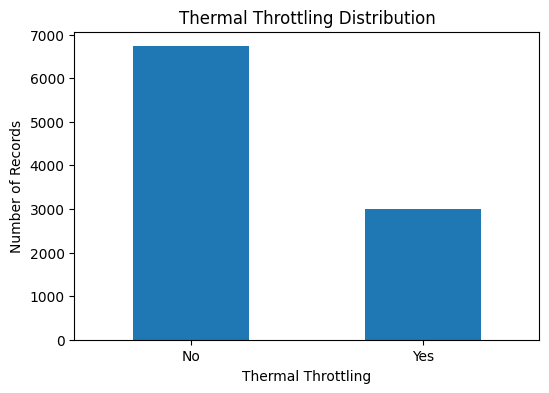

In [34]:
plt.figure(figsize=(6, 4))

data["Thermal_Throttling"].value_counts().plot(kind="bar")

plt.title("Thermal Throttling Distribution")
plt.xlabel("Thermal Throttling")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

In [35]:
feature_columns = [
    "CPU_Usage_Percent",
    "RAM_Usage_Percent",
    "GPU_Usage_Percent",
    "Ambient_Temperature_C",
    "CPU_Temperature_C",
    "GPU_Temperature_C",
    "Fan_Speed_RPM",
    "CPU_Frequency_MHz",
    "Battery_Temperature_C",
    "Battery_Level_Percent",
    "Power_Consumption_W",
    "Process_Count"
]

X = data[feature_columns]

y = data["Thermal_Throttling"]

In [36]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Encoded Target:")
print(y[:10])

print("Classes:", le.classes_)

Encoded Target:
[0 0 1 0 0 1 0 0 0 0]
Classes: ['No' 'Yes']


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=20,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7784, 12)
Testing data: (1947, 12)


In [38]:
model = GaussianNB()

model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


In [39]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7005649717514124


In [41]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))


Classification Report:
              precision    recall  f1-score   support

          No       0.79      0.78      0.78      1346
         Yes       0.51      0.52      0.52       601

    accuracy                           0.70      1947
   macro avg       0.65      0.65      0.65      1947
weighted avg       0.70      0.70      0.70      1947



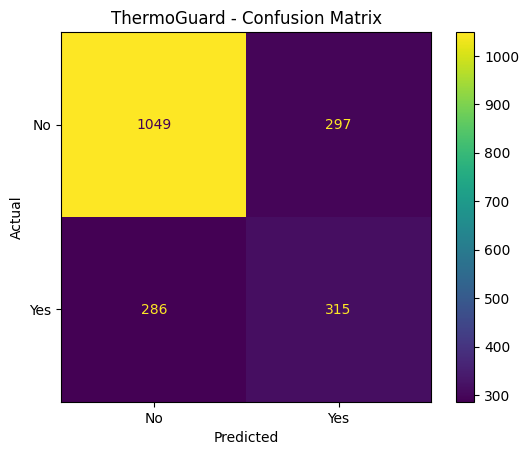

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_
)

plt.title("ThermoGuard - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1049  297]
 [ 286  315]]


In [43]:
print("\n===== THERMOGUARD PREDICTION =====")

cpu_usage = float(input("CPU Usage (%): "))
ram_usage = float(input("RAM Usage (%): "))
gpu_usage = float(input("GPU Usage (%): "))
ambient_temp = float(input("Ambient Temperature (°C): "))
cpu_temp = float(input("CPU Temperature (°C): "))
gpu_temp = float(input("GPU Temperature (°C): "))
fan_speed = float(input("Fan Speed (RPM): "))
cpu_frequency = float(input("CPU Frequency (MHz): "))
battery_temp = float(input("Battery Temperature (°C): "))
battery_level = float(input("Battery Level (%): "))
power = float(input("Power Consumption (W): "))
process_count = int(input("Process Count: "))


===== THERMOGUARD PREDICTION =====
CPU Usage (%): 90
RAM Usage (%): 98
GPU Usage (%): 89
Ambient Temperature (°C): 78
CPU Temperature (°C): 76
GPU Temperature (°C): 86
Fan Speed (RPM): 97
CPU Frequency (MHz): 96
Battery Temperature (°C): 67
Battery Level (%): 89
Power Consumption (W): 98
Process Count: 90


In [46]:
user_data = pd.DataFrame([{
    "CPU_Usage_Percent": cpu_usage,
    "RAM_Usage_Percent": ram_usage,
    "GPU_Usage_Percent": gpu_usage,
    "Ambient_Temperature_C": ambient_temp,
    "CPU_Temperature_C": cpu_temp,
    "GPU_Temperature_C": gpu_temp,
    "Fan_Speed_RPM": fan_speed,
    "CPU_Frequency_MHz": cpu_frequency,
    "Battery_Temperature_C": battery_temp,
    "Battery_Level_Percent": battery_level,
    "Power_Consumption_W": power,
    "Process_Count": process_count
}])

prediction = model.predict(user_data)

predicted_label = le.inverse_transform(prediction)[0]

print("\nPredicted Result:", predicted_label)


Predicted Result: Yes


In [47]:
if predicted_label == "Yes":

    print("\n⚠️ THERMAL THROTTLING DETECTED")
    print("Laptop temperature/load may cause performance reduction.")

else:

    print("\n✅ NORMAL")
    print("No thermal throttling detected.")


⚠️ THERMAL THROTTLING DETECTED
Laptop temperature/load may cause performance reduction.
